# DentalVision - Model Training

This notebook trains an EfficientNetB0 model to classify dental diseases from cropped dental X-ray images.

In [1]:
import os
import random
import pathlib
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.utils.class_weight import compute_class_weight

from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau
)

In [2]:
print("TensorFlow Version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

TensorFlow Version: 2.21.0
GPU: []


In [3]:
SEED = 42

tf.random.set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

In [4]:
DATASET_PATH = pathlib.Path(r"D:\FYP\dental-vision\ML\data\processed")

TRAIN_PATH = DATASET_PATH / "train"
VALID_PATH = DATASET_PATH / "valid"
TEST_PATH = DATASET_PATH / "test"

MODEL_PATH = pathlib.Path(r"D:\FYP\dental-vision\ML\models")
MODEL_PATH.mkdir(exist_ok=True)

In [23]:
IMAGE_SIZE = (224, 224)

BATCH_SIZE = 32

EPOCHS = 10

In [6]:
train_dataset = tf.keras.utils.image_dataset_from_directory(
    TRAIN_PATH,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    seed=SEED
)

valid_dataset = tf.keras.utils.image_dataset_from_directory(
    VALID_PATH,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_dataset = tf.keras.utils.image_dataset_from_directory(
    TEST_PATH,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 35437 files belonging to 5 classes.
Found 7595 files belonging to 5 classes.
Found 7596 files belonging to 5 classes.


In [7]:
class_names = train_dataset.class_names

print("Classes:")
print(class_names)

Classes:
['Bone_Loss', 'Caries', 'Impacted_Tooth', 'Missing_Teeth', 'Periapical_Lesion']


In [8]:
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.prefetch(AUTOTUNE)
valid_dataset = valid_dataset.prefetch(AUTOTUNE)
test_dataset = test_dataset.prefetch(AUTOTUNE)

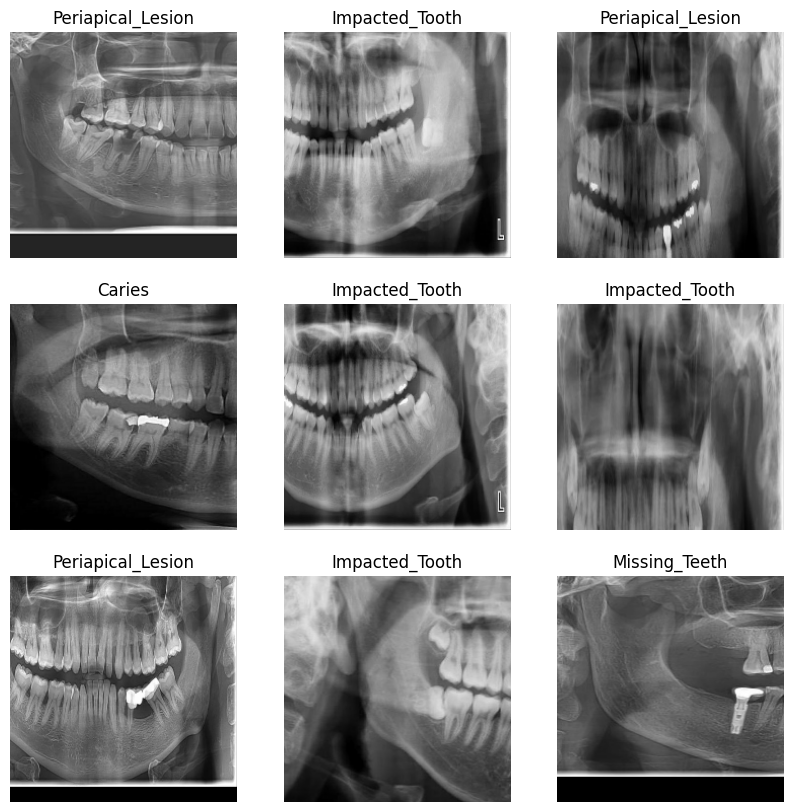

In [9]:
plt.figure(figsize=(10,10))

for images, labels in train_dataset.take(1):

    for i in range(9):

        ax = plt.subplot(3,3,i+1)

        plt.imshow(images[i].numpy().astype("uint8"))

        plt.title(class_names[labels[i]])

        plt.axis("off")

plt.show()

In [36]:
data_augmentation = tf.keras.Sequential([
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.15)
])

In [11]:
labels = []

for _, y in train_dataset:
    labels.extend(y.numpy())

labels = np.array(labels)

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(labels),
    y=labels
)

class_weights = dict(enumerate(class_weights))

print(class_weights)

{0: np.float64(3.234778639890461), 1: np.float64(0.9442312816413536), 2: np.float64(0.36189746732026146), 3: np.float64(2.8892784345699143), 4: np.float64(1.9139616527140157)}


In [12]:
base_model = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

In [13]:
inputs = tf.keras.Input(shape=(224, 224, 3))

x = data_augmentation(inputs)

x = tf.keras.applications.efficientnet.preprocess_input(x)

x = base_model(x, training=False)

x = layers.GlobalAveragePooling2D()(x)

x = layers.Dropout(0.3)(x)

outputs = layers.Dense(
    len(class_names),
    activation="softmax"
)(x)

model = tf.keras.Model(inputs, outputs)

In [14]:
inputs = tf.keras.Input(shape=(224, 224, 3))

x = data_augmentation(inputs)

x = tf.keras.applications.efficientnet.preprocess_input(x)

x = base_model(x, training=False)

x = layers.GlobalAveragePooling2D()(x)

x = layers.Dropout(0.3)(x)

outputs = layers.Dense(
    len(class_names),
    activation="softmax"
)(x)

model = tf.keras.Model(inputs, outputs)

In [15]:
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │         6,405 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,055,976 (15.47 MB)

 Trainable params: 6,405 (25.02 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [20]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [21]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    MODEL_PATH / "best_model.keras",
    monitor="val_accuracy",
    save_best_only=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=3,
    min_lr=1e-6
)

In [22]:
history = model.fit(
    train_dataset,
    validation_data=valid_dataset,
    epochs=EPOCHS,
    class_weight=class_weights,
    callbacks=[
        early_stop,
        checkpoint,
        reduce_lr
    ]
)

Epoch 1/10
1108/1108 ━━━━━━━━━━━━━━━━━━━━ 697s 625ms/step - accuracy: 0.5700 - loss: 1.2363 - val_accuracy: 0.4465 - val_loss: 1.3642 - learning_rate: 0.0010
Epoch 2/10
1108/1108 ━━━━━━━━━━━━━━━━━━━━ 662s 597ms/step - accuracy: 0.6125 - loss: 1.1448 - val_accuracy: 0.4737 - val_loss: 1.3231 - learning_rate: 0.0010
Epoch 3/10
1108/1108 ━━━━━━━━━━━━━━━━━━━━ 654s 590ms/step - accuracy: 0.6218 - loss: 1.1260 - val_accuracy: 0.5331 - val_loss: 1.1859 - learning_rate: 0.0010
Epoch 4/10
1108/1108 ━━━━━━━━━━━━━━━━━━━━ 657s 593ms/step - accuracy: 0.6194 - loss: 1.1210 - val_accuracy: 0.5085 - val_loss: 1.2154 - learning_rate: 0.0010
Epoch 5/10
1108/1108 ━━━━━━━━━━━━━━━━━━━━ 662s 597ms/step - accuracy: 0.6240 - loss: 1.1074 - val_accuracy: 0.4824 - val_loss: 1.2815 - learning_rate: 0.0010
Epoch 6/10
1108/1108 ━━━━━━━━━━━━━━━━━━━━ 714s 644ms/step - accuracy: 0.6250 - loss: 1.1072 - val_accuracy: 0.4583 - val_loss: 1.3313 - learning_rate: 0.0010
Epoch 7/10
1108/1108 ━━━━━━━━━━━━━━━━━━━━ 910s 821ms

In [24]:
best_model = tf.keras.models.load_model(
    MODEL_PATH / "best_model.keras"
)

print("Best model loaded successfully.")

Best model loaded successfully.


In [25]:
test_loss, test_accuracy = best_model.evaluate(test_dataset)

print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

238/238 ━━━━━━━━━━━━━━━━━━━━ 160s 660ms/step - accuracy: 0.5269 - loss: 1.1994

Test Loss: 1.1994
Test Accuracy: 0.5269


In [27]:
import numpy as np

predictions = best_model.predict(test_dataset)

predicted_labels = np.argmax(predictions, axis=1)

238/238 ━━━━━━━━━━━━━━━━━━━━ 111s 461ms/step


In [29]:
true_labels = np.concatenate([
    labels.numpy()
    for _, labels in test_dataset
])

In [30]:
from sklearn.metrics import classification_report

print(
    classification_report(
        true_labels,
        predicted_labels,
        target_names=class_names,
        digits=4
    )
)

                   precision    recall  f1-score   support

        Bone_Loss     0.1792    0.5638    0.2719       470
           Caries     0.6936    0.5277    0.5994      1609
   Impacted_Tooth     0.9605    0.5099    0.6661      4197
    Missing_Teeth     0.3255    0.7338    0.4509       526
Periapical_Lesion     0.2448    0.4559    0.3185       794

         accuracy                         0.5269      7596
        macro avg     0.4807    0.5582    0.4614      7596
     weighted avg     0.7368    0.5269    0.5764      7596



In [31]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(true_labels, predicted_labels)

print(cm)

[[ 265   48   14   55   88]
 [ 114  849   36  476  134]
 [ 983  152 2140   73  849]
 [  26   64    4  386   46]
 [  91  111   34  196  362]]


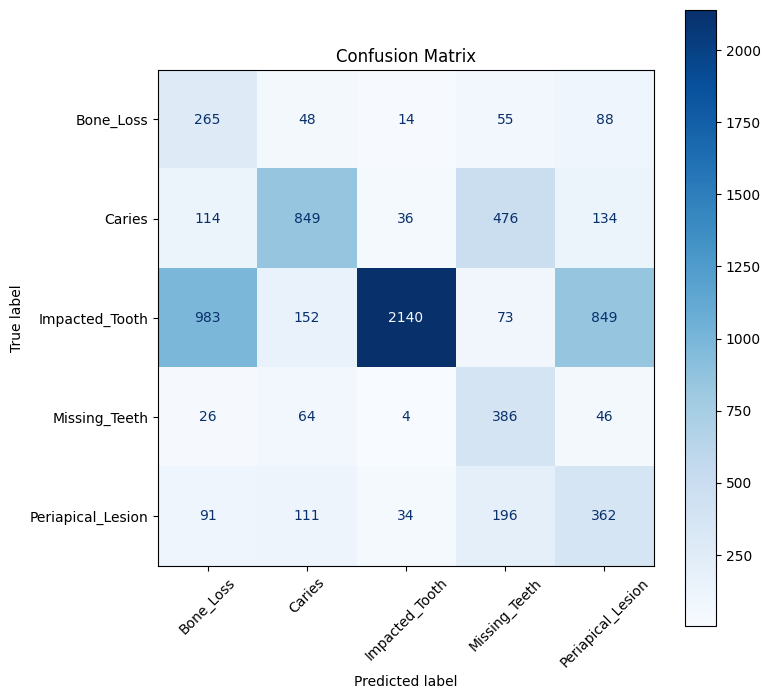

In [32]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(8,8))

disp.plot(
    ax=ax,
    cmap="Blues",
    xticks_rotation=45
)

plt.title("Confusion Matrix")
plt.show()

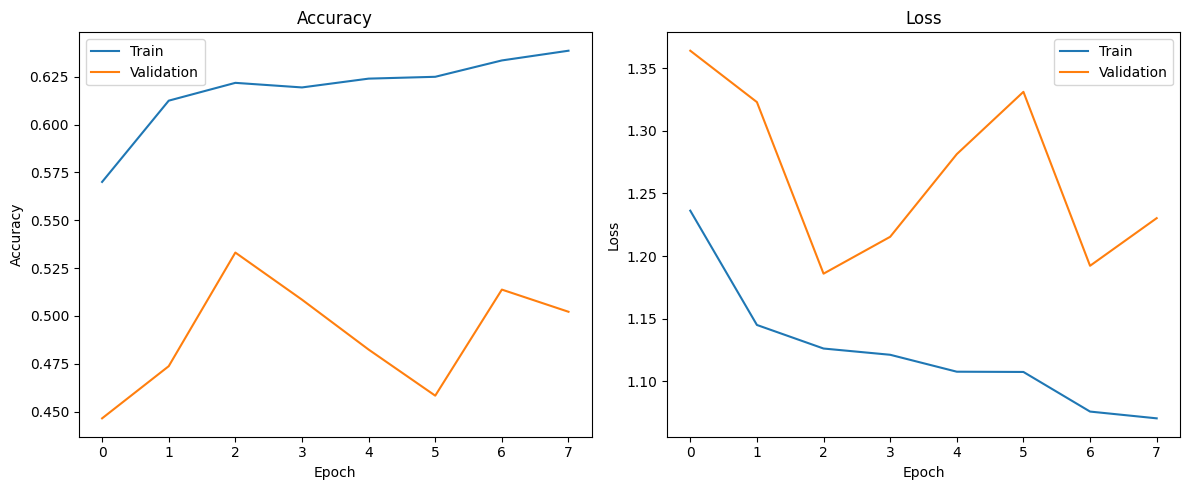

In [37]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)

plt.plot(history.history["accuracy"], label="Train")
plt.plot(history.history["val_accuracy"], label="Validation")

plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1,2,2)

plt.plot(history.history["loss"], label="Train")
plt.plot(history.history["val_loss"], label="Validation")

plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()

plt.show()

In [35]:
import pandas as pd

history_df = pd.DataFrame(history.history)

history_df.to_csv(
    MODEL_PATH / "training_history.csv",
    index=False
)

print("Training history saved.")

Training history saved.


In [38]:
base_model.trainable = True

# Fine-tune only last layers (important)
for layer in base_model.layers[:-30]:
    layer.trainable = False

In [39]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [40]:
history_finetune = model.fit(
    train_dataset,
    validation_data=valid_dataset,
    epochs=10,
    class_weight=class_weights,
    callbacks=[
        early_stop,
        checkpoint,
        reduce_lr
    ]
)

Epoch 1/10
1108/1108 ━━━━━━━━━━━━━━━━━━━━ 944s 845ms/step - accuracy: 0.5417 - loss: 1.2250 - val_accuracy: 0.4883 - val_loss: 1.3072 - learning_rate: 1.0000e-05
Epoch 2/10
1108/1108 ━━━━━━━━━━━━━━━━━━━━ 773s 697ms/step - accuracy: 0.6069 - loss: 1.1328 - val_accuracy: 0.5172 - val_loss: 1.2152 - learning_rate: 1.0000e-05
Epoch 3/10
1108/1108 ━━━━━━━━━━━━━━━━━━━━ 999s 902ms/step - accuracy: 0.6227 - loss: 1.0950 - val_accuracy: 0.5350 - val_loss: 1.1618 - learning_rate: 1.0000e-05
Epoch 4/10
1108/1108 ━━━━━━━━━━━━━━━━━━━━ 978s 844ms/step - accuracy: 0.6383 - loss: 1.0572 - val_accuracy: 0.5293 - val_loss: 1.1615 - learning_rate: 1.0000e-05
Epoch 5/10
1108/1108 ━━━━━━━━━━━━━━━━━━━━ 846s 763ms/step - accuracy: 0.6478 - loss: 1.0294 - val_accuracy: 0.5346 - val_loss: 1.1322 - learning_rate: 1.0000e-05
Epoch 6/10
1108/1108 ━━━━━━━━━━━━━━━━━━━━ 980s 884ms/step - accuracy: 0.6541 - loss: 1.0102 - val_accuracy: 0.5583 - val_loss: 1.0792 - learning_rate: 1.0000e-05
Epoch 7/10
1108/1108 ━━━━━━━

In [43]:
best_model = tf.keras.models.load_model(
    MODEL_PATH / "fine_tuned_model.keras"
)

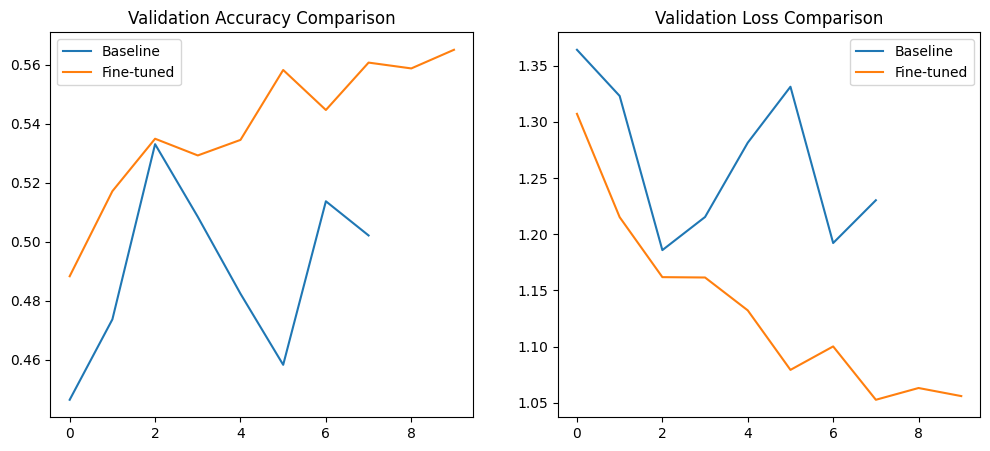

In [42]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history["val_accuracy"], label="Baseline")
plt.plot(history_finetune.history["val_accuracy"], label="Fine-tuned")
plt.title("Validation Accuracy Comparison")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history["val_loss"], label="Baseline")
plt.plot(history_finetune.history["val_loss"], label="Fine-tuned")
plt.title("Validation Loss Comparison")
plt.legend()

plt.show()

In [44]:
best_model = tf.keras.models.load_model(
    MODEL_PATH / "fine_tuned_model.keras"
)

print("Fine-tuned model loaded successfully!")

Fine-tuned model loaded successfully!


In [45]:
test_loss, test_accuracy = best_model.evaluate(test_dataset)

print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

238/238 ━━━━━━━━━━━━━━━━━━━━ 95s 385ms/step - accuracy: 0.5511 - loss: 1.0718

Test Loss: 1.0718
Test Accuracy: 0.5511


In [46]:
predictions = best_model.predict(test_dataset)

predicted_labels = np.argmax(predictions, axis=1)

238/238 ━━━━━━━━━━━━━━━━━━━━ 95s 392ms/step


In [47]:
from sklearn.metrics import classification_report

print(classification_report(
    true_labels,
    predicted_labels,
    target_names=class_names,
    digits=4
))

                   precision    recall  f1-score   support

        Bone_Loss     0.1618    0.6234    0.2569       470
           Caries     0.7231    0.5712    0.6382      1609
   Impacted_Tooth     0.9641    0.5239    0.6789      4197
    Missing_Teeth     0.3522    0.7567    0.4807       526
Periapical_Lesion     0.3418    0.4748    0.3975       794

         accuracy                         0.5511      7596
        macro avg     0.5086    0.5900    0.4904      7596
     weighted avg     0.7560    0.5511    0.6010      7596



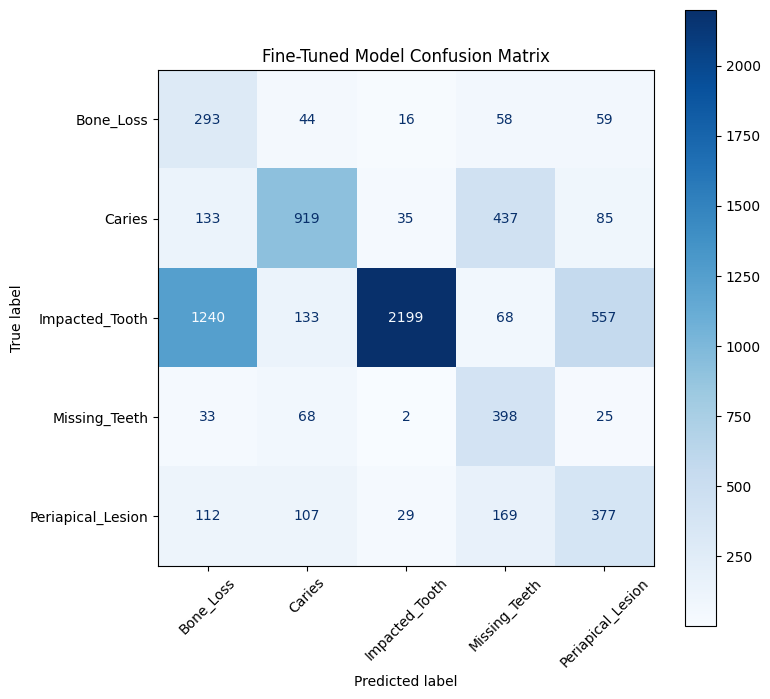

In [48]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(true_labels, predicted_labels)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(ax=ax, cmap="Blues", xticks_rotation=45)
plt.title("Fine-Tuned Model Confusion Matrix")
plt.show()

In [49]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import pandas as pd

accuracy = accuracy_score(true_labels, predicted_labels)
precision, recall, f1, _ = precision_recall_fscore_support(
    true_labels,
    predicted_labels,
    average="weighted"
)

results = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score"],
    "Value": [accuracy, precision, recall, f1]
})

print(results)

results.to_csv(MODEL_PATH / "evaluation_results.csv", index=False)

print("\nEvaluation results saved successfully!")

      Metric     Value
0   Accuracy  0.551080
1  Precision  0.755951
2     Recall  0.551080
3   F1-Score  0.601030

Evaluation results saved successfully!
